## LASSO REGRESSION
**LASSO :** Une méthode de régression qui applique une régularisation L1, ce qui peut réduire certains coefficients à zéro, effectuant ainsi une sélection de variables.

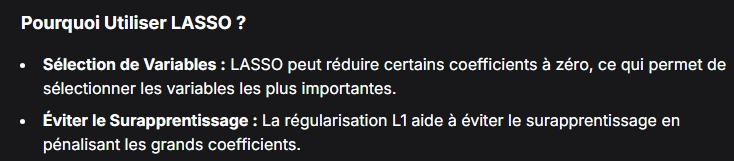
**When to Use Lasso Regression?**  

 -> When you want to perform feature selection (some coefficients can become exactly zero).  
 -> When you have a large number of features and suspect that only a subset of them is relevant.  


In [15]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('https://raw.githubusercontent.com/acakin/hitters/refs/heads/master/hitters.csv')
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [19]:
df['Salary'].fillna(df['Salary'].median(skipna=True), inplace=True)
df.isna().sum()
#If you run df.isna().sum() on this DataFrame, and all columns show 0.
# In this output, every column has a 0, which means there are no missing values in any of the columns.

C:\Users\imane\AppData\Local\Temp\ipykernel_26684\2821702337.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].median(skipna=True), inplace=True)


AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

In [20]:
# One-hot encode categorical variables
dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']], drop_first=True)

# Define target variable
y = df['Salary']

# Define feature variables, excluding unnecessary columns and converting to float64
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')

# Concatenate numerical features and dummy variables
X = pd.concat([X_, dms], axis=1)

In [21]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
# Initialize and fit the Lasso regression model
lasso_model = Lasso().fit(X_train, y_train)

c:\Users\imane\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.923e+06, tolerance: 3.853e+03
  model = cd_fast.enet_coordinate_descent(


In [23]:
# Retrieve the intercept of the model
intercept = lasso_model.intercept_
print(f'Intercept: {intercept}')

Intercept: 342.8733925858769


In [24]:
# Retrieve the coefficients of the model
coefficients = lasso_model.coef_
print(f'Coefficients: {coefficients}')

Coefficients: [-1.98558949e+00  5.50494749e+00  4.79612807e+00  1.02123896e-01
 -8.11521080e-01  4.87004116e+00 -9.97808288e+00 -2.19391227e-01
  6.16237616e-01  9.03214960e-03  8.73990383e-01  7.84172593e-01
 -8.13423037e-01  1.83989460e-01  4.04846687e-01 -4.08650952e+00
  2.67092023e+01 -1.11463261e+02 -0.00000000e+00]


In [25]:
# Make predictions on the test set
y_pred = lasso_model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse}')

RMSE: 345.6190692407428


In [26]:
# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.3657513009571691


In [27]:
# Initialize and fit the LassoCV model
alphas = np.random.randint(0, 1000, 100)
lasso_cv_model = LassoCV(alphas=alphas, cv=10, max_iter=1000, n_jobs=-1).fit(X_train, y_train)

c:\Users\imane\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.341e+04, tolerance: 3.465e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\imane\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.708e+03, tolerance: 3.587e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\imane\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

In [28]:
# Retrieve and display the coefficients of the tuned model
tuned_coefficients = pd.Series(lasso_cv_model.coef_, index=X_train.columns)
print(tuned_coefficients)

AtBat          -1.918086
Hits            5.126820
HmRun           2.443879
Runs            0.295663
RBI            -0.000000
Walks           4.821499
Years          -3.879546
CAtBat         -0.263819
CHits           0.734330
CHmRun          0.132193
CRuns           0.864787
CRBI            0.735014
CWalks         -0.786518
PutOuts         0.178432
Assists         0.382404
Errors         -2.613340
League_N        0.000000
Division_W    -55.486277
NewLeague_N     0.000000
dtype: float64


In [29]:
# Make predictions on the test set using the tuned model
y_pred_tuned = lasso_cv_model.predict(X_test)

# Calculate RMSE for the tuned model
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print(f'Tuned RMSE: {rmse_tuned}')

Tuned RMSE: 346.70839160783527


**Summary of the Workflow:**

`Preprocess Categorical Variables:` Convert categorical variables to dummy variables.  
`Define Features and Target:` Separate the dataset into features and target variable.  
`Split Data:` Divide the data into training and testing sets.  
`Train Lasso Model:` Fit a Lasso regression model to the training data.  
`Evaluate Model:` Make predictions and evaluate the model using RMSE and R-squared.  
`Tune Lasso Model:` Use cross-validation to find the optimal alpha for the Lasso model.  
`Evaluate Tuned Model:` Make predictions and evaluate the tuned model.  
